<a href="https://colab.research.google.com/github/Arif118/Stock-market-predictor/blob/main/Stock_Market_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [299]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [300]:
df = pd.read_json('/content/msft_data.json')

In [301]:
df.head(5)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
1986-03-13 05:00:00,0.053963,0.061899,0.053963,0.059253,1031788800,0.0,0.0
1986-03-14 05:00:00,0.059253,0.062428,0.059253,0.061369,308160000,0.0,0.0
1986-03-17 05:00:00,0.061369,0.062957,0.061369,0.062428,133171200,0.0,0.0
1986-03-18 05:00:00,0.062428,0.062957,0.060311,0.060840,67766400,0.0,0.0
1986-03-19 05:00:00,0.060840,0.061369,0.059253,0.059782,47894400,0.0,0.0


In [302]:
df.shape

(10117, 7)

In [303]:
df["Date"]=df.index
df.reset_index(drop=True, inplace=True)

In [304]:
df.head(5)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Date
0,0.053963,0.061899,0.053963,0.059253,1031788800,0.0,0.0,1986-03-13 05:00:00
1,0.059253,0.062428,0.059253,0.061369,308160000,0.0,0.0,1986-03-14 05:00:00
2,0.061369,0.062957,0.061369,0.062428,133171200,0.0,0.0,1986-03-17 05:00:00
3,0.062428,0.062957,0.060311,0.060840,67766400,0.0,0.0,1986-03-18 05:00:00
4,0.060840,0.061369,0.059253,0.059782,47894400,0.0,0.0,1986-03-19 05:00:00


In [305]:
del df['Dividends']
del df['Stock Splits']
df.head(5)

,Open,High,Low,Close,Volume,Date
0,0.053963,0.061899,0.053963,0.059253,1031788800,1986-03-13 05:00:00
1,0.059253,0.062428,0.059253,0.061369,308160000,1986-03-14 05:00:00
2,0.061369,0.062957,0.061369,0.062428,133171200,1986-03-17 05:00:00
3,0.062428,0.062957,0.060311,0.060840,67766400,1986-03-18 05:00:00
4,0.060840,0.061369,0.059253,0.059782,47894400,1986-03-19 05:00:00


<Axes: xlabel='Date', ylabel='Close'>

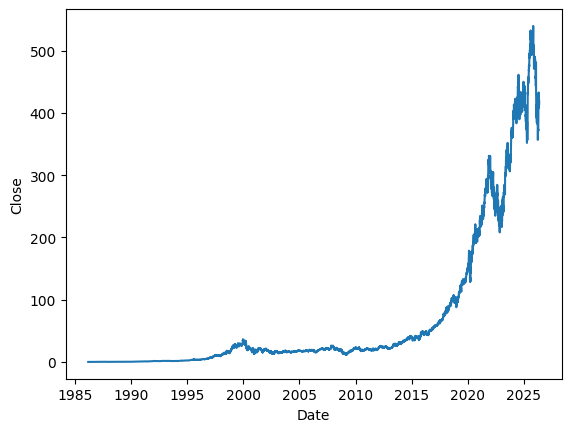

In [306]:
sns.lineplot(x="Date",y='Close', data=df)

Older stock market data may not represent current market behavior.So We select recent rows to focus on modern market patterns.

In [307]:
df = df.loc['5000':].copy()
df.head(5)

,Open,High,Low,Close,Volume,Date
5000,18.755923,18.874191,18.721139,18.776794,48245500,2006-01-05 05:00:00
5001,18.707220,18.783747,18.428943,18.721134,100963000,2006-01-06 05:00:00
5002,18.735050,18.832447,18.616782,18.686352,55625000,2006-01-09 05:00:00
5003,18.540253,18.797661,18.498512,18.783747,64921900,2006-01-10 05:00:00
5004,18.790711,19.055074,18.714184,18.985506,70120700,2006-01-11 05:00:00


In [308]:
df.shape

(5117, 6)

<Axes: xlabel='Date', ylabel='Close'>

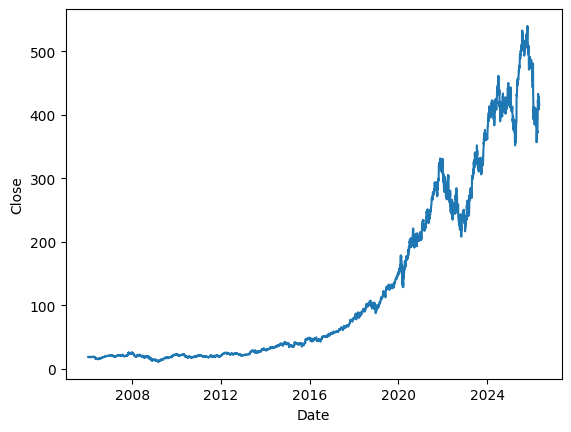

In [309]:
sns.lineplot(x="Date",y='Close', data=df)

**Shifting the closing price** upward by one row so that each row contains tomorrow's closing price.

In [310]:
df['Tomorrow'] = df['Close'].shift(-1)
df.tail(5)

,Open,High,Low,Close,Volume,Date,Tomorrow
10112,411.540009,420.779999,410.799988,413.619995,28066500,2026-05-04 04:00:00,411.380005
10113,415.320007,416.779999,408.799988,411.380005,25700900,2026-05-05 04:00:00,413.959991
10114,408.000000,418.420013,405.109985,413.959991,30285900,2026-05-06 04:00:00,420.769989
10115,420.109985,427.980011,418.760010,420.769989,34942400,2026-05-07 04:00:00,415.369995
10116,417.385010,418.630005,414.000000,415.369995,22709488,2026-05-08 04:00:00,NaN


In [311]:
df.dropna(inplace=True)
df

,Open,High,Low,Close,Volume,Date,Tomorrow
5000,18.755923,18.874191,18.721139,18.776794,48245500,2006-01-05 05:00:00,18.721134
5001,18.707220,18.783747,18.428943,18.721134,100963000,2006-01-06 05:00:00,18.686352
5002,18.735050,18.832447,18.616782,18.686352,55625000,2006-01-09 05:00:00,18.783747
5003,18.540253,18.797661,18.498512,18.783747,64921900,2006-01-10 05:00:00,18.985506
5004,18.790711,19.055074,18.714184,18.985506,70120700,2006-01-11 05:00:00,18.881142
...,...,...,...,...,...,...,...
10111,412.799988,417.109985,410.440002,414.440002,31372400,2026-05-01 04:00:00,413.619995
10112,411.540009,420.779999,410.799988,413.619995,28066500,2026-05-04 04:00:00,411.380005
10113,415.320007,416.779999,408.799988,411.380005,25700900,2026-05-05 04:00:00,413.959991
10114,408.000000,418.420013,405.109985,413.959991,30285900,2026-05-06 04:00:00,420.769989


In [312]:
df['Target']=df['Tomorrow']>=df['Close']
df['Target'] = df['Target'].astype(int)
df.head(5)

,Open,High,Low,Close,Volume,Date,Tomorrow,Target
5000,18.755923,18.874191,18.721139,18.776794,48245500,2006-01-05 05:00:00,18.721134,0
5001,18.707220,18.783747,18.428943,18.721134,100963000,2006-01-06 05:00:00,18.686352,0
5002,18.735050,18.832447,18.616782,18.686352,55625000,2006-01-09 05:00:00,18.783747,1
5003,18.540253,18.797661,18.498512,18.783747,64921900,2006-01-10 05:00:00,18.985506,1
5004,18.790711,19.055074,18.714184,18.985506,70120700,2006-01-11 05:00:00,18.881142,0


#Normal Random Split Is Wrong

For stock market prediction, future data must NEVER be used to predict the past.

Therefore, older rows become training data newer rows become testing data.

In [313]:
train = df.iloc[:-216]
test = df.iloc[-216:]
train.shape, test.shape

((4900, 8), (216, 8))

Random forest workes well on **non-linear data**.

In [314]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

In [315]:
predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

RandomForestClassifier(min_samples_split=100, random_state=1)

#Precision Instead of Accuracy
In stock market prediction: false positive predictions can be costly.

Precision measures When the model predicts stock price will increase and also how often is it correct.

In [316]:
from sklearn.metrics import precision_score
preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
score1=precision_score(test["Target"], preds)
score1

0.5024875621890548

Combining helps to compare actual movement and predicted movement.

In [317]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.head(5)

,Target,0
9900,0,1
9901,0,1
9902,1,1
9903,0,1
9904,0,1


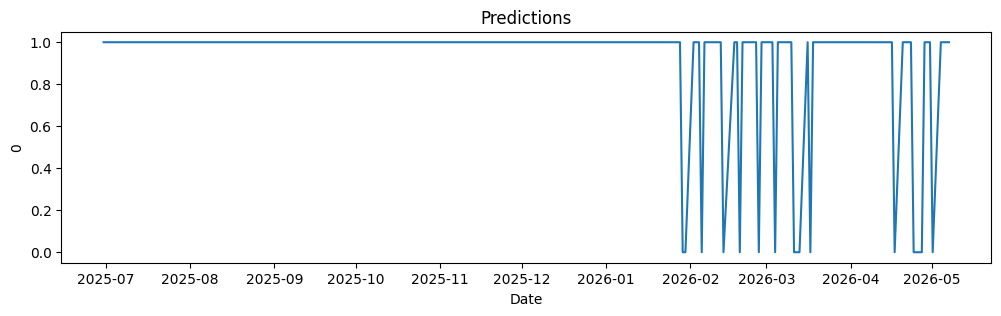

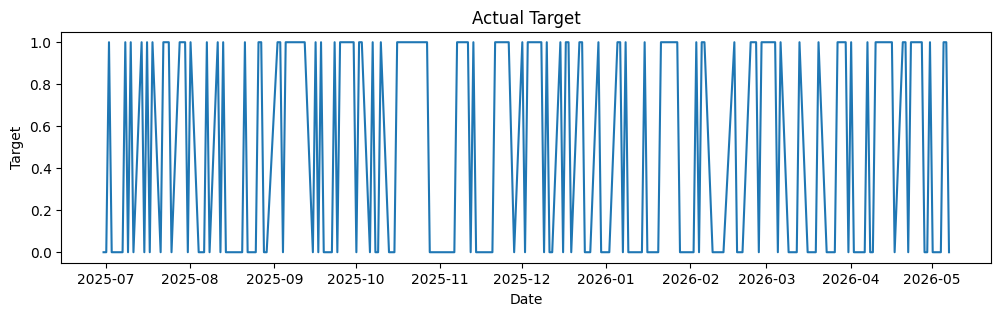

<Axes: title={'center': 'Togather'}, xlabel='Date', ylabel='0'>

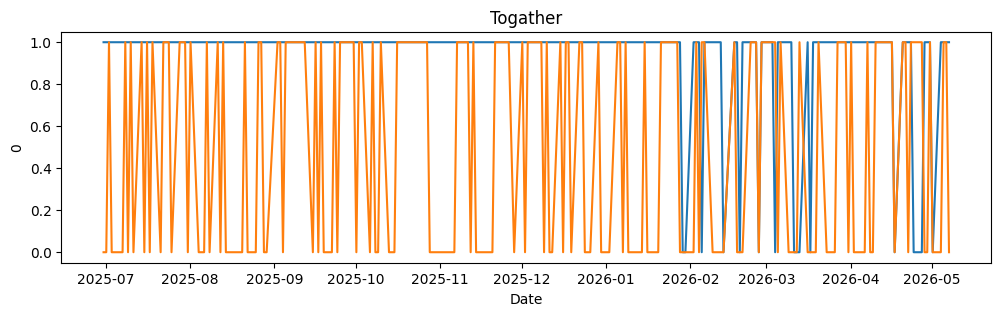

In [318]:
# Plot predictions
plt.figure(figsize=(12,3))
sns.lineplot(x=df['Date'], y=combined[0])
plt.title("Predictions")
plt.show()

# Plot actual target
plt.figure(figsize=(12,3))
sns.lineplot(x=df['Date'], y=combined['Target'])
plt.title("Actual Target")
plt.show()

plt.figure(figsize=(12,3))
plt.title("Togather")
sns.lineplot(x=df['Date'], y=combined[0])
sns.lineplot(x=df['Date'], y=combined['Target'])

This function trains the model, predicts stock movement, returns combined output.

In [319]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

#Backtesting
Instead of training once, the model repeatedly trains on past data.

In [320]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)

    return pd.concat(all_predictions)

In [321]:
predictions = backtest(df, model, predictors)

In [322]:
predictions["Predictions"].value_counts()

,count
Predictions,
0,1505
1,1111


In [323]:
score2=precision_score(predictions["Target"], predictions["Predictions"])
score2

0.5283528352835284

In [324]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
1,0.541284
0,0.458716


#Rolling Windows
Raw stock prices often fail to capture deeper market patterns. We create new features using:rolling averages, historical trends, multiple time horizons.

In [325]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
    rolling_averages = df.rolling(horizon).mean(numeric_only=True)

    ratio_column = f"Close_Ratio_{horizon}"
    df[ratio_column] = df["Close"] / rolling_averages["Close"]

    trend_column = f"Trend_{horizon}"
    df[trend_column] = df.shift(1).rolling(horizon).sum(numeric_only=True)["Target"]

    new_predictors+= [ratio_column, trend_column]

Rolling calculations create NaN values at the beginning because enough previous rows do not exist.

In [326]:
df.dropna(inplace=True)
df.head(5)

,Open,High,Low,Close,Volume,Date,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
6000,23.025184,23.114660,22.935708,23.114660,11083900,2009-12-24 05:00:00,23.241428,1,1.001292,2.0,1.008983,5.0,1.091838,38.0,1.371624,146.0,1.213760,517.0
6001,23.114670,23.248885,23.032650,23.241428,25384000,2009-12-28 05:00:00,23.405464,1,1.002735,2.0,1.009195,5.0,1.093718,39.0,1.376157,146.0,1.220127,518.0
6002,23.375640,23.487484,23.286163,23.405464,29716200,2009-12-29 05:00:00,23.084833,0,1.003517,2.0,1.010625,5.0,1.097241,39.0,1.382843,146.0,1.228434,519.0
6003,23.226504,23.330894,22.965532,23.084833,42006200,2009-12-30 05:00:00,22.726933,0,0.993103,1.0,0.995882,4.0,1.078172,39.0,1.361238,145.0,1.211332,518.0
6004,23.099750,23.107206,22.726933,22.726933,31929700,2009-12-31 05:00:00,23.077381,1,0.992188,0.0,0.983226,3.0,1.058090,38.0,1.337680,144.0,1.192318,517.0


In [327]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

This predicts upward movement only if confidence is at least 60%.

In [328]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >=.6] = 1
    preds[preds <.6] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [329]:
predictions = backtest(df, model, new_predictors, start=500)

In [330]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,3191
1.0,425


In [331]:
score3=precision_score(predictions["Target"], predictions["Predictions"])
score3

0.5270588235294118

In [332]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
1,0.532909
0,0.467091


In [333]:
predictions

,Target,Predictions
6500,1,0.0
6501,0,0.0
6502,1,0.0
6503,1,0.0
6504,1,0.0
...,...,...
10111,0,0.0
10112,0,0.0
10113,1,0.0
10114,1,0.0


#The conclusion

In [334]:
print("Precision score on Raw data:",score1)
print("Precision score on Backtested data:",score2)
print("Precision score on Rolling data:",score3)

Precision score on Raw data: 0.5024875621890548
Precision score on Backtested data: 0.5283528352835284
Precision score on Rolling data: 0.5270588235294118
